# Phase 1 — Lesson 6
## Resampling: Upsampling and Downsampling — EUR/USD H4 Practice

This notebook applies **Lesson 6** directly to your EUR/USD 4-hour dataset.

**Dataset path**

```text
Data/EURUSD_H4.csv
```

### Learning goals

By the end of this notebook, you will be able to:

1. Load and prepare EUR/USD H4 time-series data.
2. Confirm the dominant 4-hour sampling interval.
3. Downsample H4 candles to daily, weekly, and monthly candles.
4. Apply the correct **OHLC aggregation rules** for financial data.
5. Upsample H4 timestamps to hourly frequency.
6. Compare `asfreq()`, forward fill, and interpolation.
7. Understand why generated/interpolated values are **not real market candles**.
8. Identify weekend and other gaps in Forex data.

## 1. Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

## 2. Load `EURUSD_H4.csv`

Your file may contain headers, or it may contain raw MetaTrader-style rows such as:

```text
2009.12.21,00:00,...
```

The loader below supports both.

In [2]:
data_path = Path("Data/EURUSD240.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"File not found: {data_path.resolve()}\n"
        "Make sure the notebook is opened from the project folder that contains the Data folder."
    )

temp = pd.read_csv(data_path)
column_lookup = {str(c).strip().lower(): c for c in temp.columns}

if "date" in column_lookup and "time" in column_lookup:
    eurusd = temp.copy()
    eurusd = eurusd.rename(columns={
        column_lookup["date"]: "Date",
        column_lookup["time"]: "Time"
    })
else:
    eurusd = pd.read_csv(data_path, header=None)
    standard_names = [
        "Date", "Time", "Open", "High", "Low", "Close",
        "Tick_Volume", "Volume", "Spread"
    ]
    if eurusd.shape[1] <= len(standard_names):
        eurusd.columns = standard_names[:eurusd.shape[1]]
    else:
        extra_count = eurusd.shape[1] - len(standard_names)
        eurusd.columns = standard_names + [f"Extra_{i+1}" for i in range(extra_count)]

eurusd.head()

,Date,Time,Open,High,Low,Close,Tick_Volume
0,2009.12.21,00:00,1.43110,1.43470,1.43110,1.43420,5504
1,2009.12.21,04:00,1.43420,1.43570,1.43270,1.43340,5234
2,2009.12.21,08:00,1.43340,1.43420,1.42800,1.43370,8366
3,2009.12.21,12:00,1.43370,1.43710,1.43300,1.43330,8456
4,2009.12.21,16:00,1.43320,1.43350,1.42860,1.42940,8488


## 3. Create the DateTime index

For resampling, Pandas needs a proper time index. We combine `Date` and `Time` into one `DateTime` value.

In [3]:
datetime_text = (
    eurusd["Date"].astype(str).str.strip()
    + " "
    + eurusd["Time"].astype(str).str.strip()
)

eurusd["DateTime"] = pd.to_datetime(
    datetime_text,
    format="%Y.%m.%d %H:%M",
    errors="coerce"
)

if eurusd["DateTime"].isna().mean() > 0.50:
    eurusd["DateTime"] = pd.to_datetime(datetime_text, errors="coerce")

eurusd = eurusd.dropna(subset=["DateTime"])

for col in ["Open", "High", "Low", "Close", "Tick_Volume", "Volume", "Spread"]:
    if col in eurusd.columns:
        eurusd[col] = pd.to_numeric(eurusd[col], errors="coerce")

eurusd = (
    eurusd
    .drop(columns=["Date", "Time"], errors="ignore")
    .set_index("DateTime")
    .sort_index()
)

eurusd.head()

,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-21 00:00:00,1.43110,1.43470,1.43110,1.43420,5504
2009-12-21 04:00:00,1.43420,1.43570,1.43270,1.43340,5234
2009-12-21 08:00:00,1.43340,1.43420,1.42800,1.43370,8366
2009-12-21 12:00:00,1.43370,1.43710,1.43300,1.43330,8456
2009-12-21 16:00:00,1.43320,1.43350,1.42860,1.42940,8488


## 4. Inspect the dataset

In [32]:
print("Shape:", eurusd.shape)
print("Start:", eurusd.index.min())
print("End:", eurusd.index.max())
print("Columns:", eurusd.columns.tolist())

eurusd.info()

Shape: (13351, 5)
Start: 2009-12-21 00:00:00
End: 2026-09-01 12:00:00
Columns: ['Open', 'High', 'Low', 'Close', 'Tick_Volume']
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13351 entries, 2009-12-21 00:00:00 to 2026-09-01 12:00:00
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         13351 non-null  float64
 1   High         13351 non-null  float64
 2   Low          13351 non-null  float64
 3   Close        13351 non-null  float64
 4   Tick_Volume  13351 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 1.1 MB


### Check duplicated timestamps

In [5]:
duplicate_count = eurusd.index.duplicated().sum()
print("Duplicated timestamps:", duplicate_count)

if duplicate_count > 0:
    display(eurusd[eurusd.index.duplicated(keep=False)].head(10))

Duplicated timestamps: 0


## 5. Confirm the H4 frequency

For a perfect H4 series, the difference between consecutive timestamps is:

$$
4\text{ hours}
$$

Forex markets close during weekends, so larger gaps are normal.

In [6]:
time_differences = eurusd.index.to_series().diff()
time_differences.value_counts().head(10)

DateTime
0 days 04:00:00    12887
2 days 04:00:00      438
1 days 08:00:00        4
3 days 08:00:00        2
3 days 04:00:00        2
3 days 12:00:00        2
1 days 16:00:00        2
0 days 08:00:00        2
0 days 16:00:00        2
1 days 12:00:00        2
Name: count, dtype: int64

You should expect the most common interval to be:

```text
0 days 04:00:00
```

Larger gaps often represent weekend market closure.

In [7]:
four_hours = pd.Timedelta(hours=4)
h4_ratio = (time_differences == four_hours).mean()
print(f"Percentage of consecutive observations exactly 4 hours apart: {h4_ratio:.2%}")

Percentage of consecutive observations exactly 4 hours apart: 96.52%


# Part A — Downsampling

## 6. What is downsampling?

Downsampling converts a **higher-frequency** series into a **lower-frequency** series.

For this dataset:

```text
H4 → Daily
H4 → Weekly
H4 → Monthly
```

For financial candles, preserve market structure using:

- **Open** → first
- **High** → maximum
- **Low** → minimum
- **Close** → last
- **Volume** → sum, when available

## 7. Build the OHLC aggregation rules

In [8]:
ohlc_agg = {}

if "Open" in eurusd.columns:
    ohlc_agg["Open"] = "first"
if "High" in eurusd.columns:
    ohlc_agg["High"] = "max"
if "Low" in eurusd.columns:
    ohlc_agg["Low"] = "min"
if "Close" in eurusd.columns:
    ohlc_agg["Close"] = "last"

for volume_col in ["Tick_Volume", "Volume"]:
    if volume_col in eurusd.columns:
        ohlc_agg[volume_col] = "sum"

if "Spread" in eurusd.columns:
    ohlc_agg["Spread"] = "mean"

ohlc_agg

{'Open': 'first',
 'High': 'max',
 'Low': 'min',
 'Close': 'last',
 'Tick_Volume': 'sum'}

## 8. H4 → Daily OHLC

In [9]:
daily = eurusd.resample("1D").agg(ohlc_agg)
daily = daily.dropna(subset=["Close"])
daily.head(10)

,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-21,1.43110,1.43710,1.42650,1.42740,40886
2009-12-22,1.42730,1.43300,1.42180,1.42540,46509
2009-12-23,1.42530,1.43650,1.42340,1.43290,39041
2009-12-24,1.43270,1.44160,1.43270,1.43530,24485
2009-12-28,1.43710,1.44120,1.43540,1.43710,29067
2009-12-29,1.43710,1.44560,1.43310,1.43500,40983
2009-12-30,1.43500,1.43590,1.42720,1.43350,41990
2009-12-31,1.43360,1.44390,1.43060,1.43310,34103
2010-01-04,1.43240,1.44540,1.42570,1.44120,52457


### Compare observation counts

In [10]:
print("H4 observations :", len(eurusd))
print("Daily candles    :", len(daily))
print("Reduction        :", len(eurusd) - len(daily))

H4 observations : 13351
Daily candles    : 2439
Reduction        : 10912


### Verify one daily candle manually

$$
Open_{day}=\text{first H4 Open}
$$

$$
High_{day}=\max(H4\ High)
$$

$$
Low_{day}=\min(H4\ Low)
$$

$$
Close_{day}=\text{last H4 Close}
$$

In [11]:
example_day = daily.index[0].date()
print("H4 candles for:", example_day)
display(eurusd.loc[str(example_day)])

print("Daily candle:")
display(daily.loc[[str(example_day)]])

H4 candles for: 2009-12-21


,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-21 00:00:00,1.43110,1.43470,1.43110,1.43420,5504
2009-12-21 04:00:00,1.43420,1.43570,1.43270,1.43340,5234
2009-12-21 08:00:00,1.43340,1.43420,1.42800,1.43370,8366
2009-12-21 12:00:00,1.43370,1.43710,1.43300,1.43330,8456
2009-12-21 16:00:00,1.43320,1.43350,1.42860,1.42940,8488
2009-12-21 20:00:00,1.42940,1.42960,1.42650,1.42740,4838


Daily candle:


,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-21,1.43110,1.43710,1.42650,1.42740,40886


## 9. H4 → Weekly OHLC

In [12]:
weekly = eurusd.resample("W-FRI").agg(ohlc_agg)
weekly = weekly.dropna(subset=["Close"])
weekly.head(10)

,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-25,1.43110,1.44160,1.42180,1.43530,150921
2010-01-01,1.43710,1.44560,1.42720,1.43310,146143
2010-01-08,1.43240,1.44830,1.42570,1.44080,262693
2010-01-15,1.44110,1.45780,1.43360,1.43840,270562
2010-01-22,1.43480,1.44130,1.40280,1.41360,289396
2010-01-29,1.41500,1.41930,1.38610,1.38610,287208
2010-02-05,1.38620,1.40240,1.35860,1.36760,284637
2010-02-12,1.36550,1.38380,1.35310,1.36300,292022
2010-02-19,1.36150,1.37870,1.34440,1.36100,258901


`W-FRI` creates weekly periods ending on Friday, which is convenient for Forex analysis.

## 10. H4 → Monthly OHLC

In [13]:
monthly = eurusd.resample("ME").agg(ohlc_agg)
monthly = monthly.dropna(subset=["Close"])
monthly.head()

,Open,High,Low,Close,Tick_Volume
DateTime,,,,,
2009-12-31,1.43110,1.44560,1.42180,1.43310,297064
2010-01-31,1.43240,1.45780,1.38610,1.38610,1109859
2010-02-28,1.38620,1.40240,1.34440,1.36300,1101444
2010-03-31,1.36220,1.38160,1.32670,1.35060,931711
2010-04-30,1.35060,1.36900,1.31140,1.32920,894397


## 11. Compare H4 and Daily Close visually

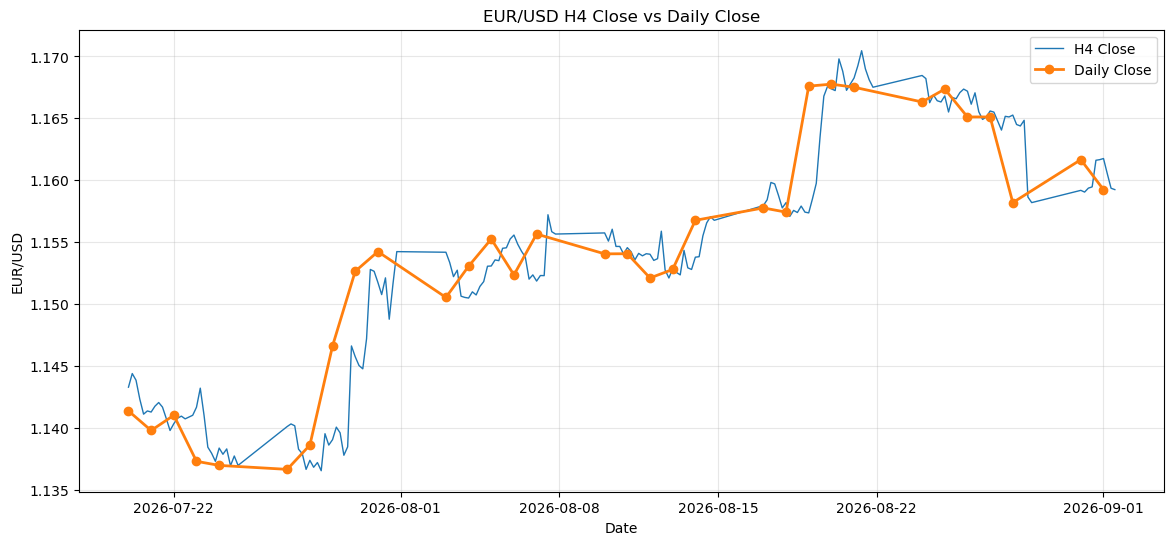

In [14]:
plot_end = eurusd.index.max()
plot_start = plot_end - pd.Timedelta(days=45)

h4_plot = eurusd.loc[plot_start:plot_end]
daily_plot = daily.loc[plot_start:plot_end]

plt.figure(figsize=(14, 6))
plt.plot(h4_plot.index, h4_plot["Close"], label="H4 Close", linewidth=1)
plt.plot(daily_plot.index, daily_plot["Close"], marker="o", label="Daily Close", linewidth=2)
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 Close vs Daily Close")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The daily series has fewer observations and removes intraday detail. This is the core effect of **downsampling**.

## 12. A common mistake: averaging all OHLC columns

This code is valid Pandas:

```python
eurusd.resample("1D").mean()
```

but averaging `Open`, `High`, `Low`, and `Close` does **not** create a correct daily candle.

In [15]:
daily_average = eurusd[["Close"]].resample("1D").mean().dropna()

comparison = pd.DataFrame({
    "Daily_Close": daily["Close"],
    "Average_H4_Close": daily_average["Close"]
})

comparison.head(10)

,Daily_Close,Average_H4_Close
DateTime,,
2009-12-21,1.42740,1.43190
2009-12-22,1.42540,1.42830
2009-12-23,1.43290,1.42855
2009-12-24,1.43530,1.43664
2009-12-28,1.43710,1.43882
2009-12-29,1.43500,1.43813
2009-12-30,1.43350,1.43287
2009-12-31,1.43310,1.43822
2010-01-04,1.44120,1.43685


- **Daily Close** = final H4 close of the trading day.
- **Average H4 Close** = average of the day's H4 closing prices.

They answer different questions.

# Part B — Upsampling

## 13. What is upsampling?

Upsampling converts a **lower-frequency** series into a **higher-frequency** series.

For this dataset:

```text
H4 → H1
```

New hourly timestamps are created between the real H4 observations.

> New timestamps do not mean new real market observations.

## 14. H4 Close → Hourly using `.asfreq()`

In [16]:
sample_start = eurusd.index.min()
sample_end = sample_start + pd.Timedelta(days=7)

h4_sample = eurusd.loc[sample_start:sample_end, ["Close"]].copy()
hourly_asfreq = h4_sample.resample("1h").asfreq()

hourly_asfreq.head(20)

,Close
DateTime,
2009-12-21 00:00:00,1.43420
2009-12-21 01:00:00,NaN
2009-12-21 02:00:00,NaN
2009-12-21 03:00:00,NaN
2009-12-21 04:00:00,1.43340
2009-12-21 05:00:00,NaN
2009-12-21 06:00:00,NaN
2009-12-21 07:00:00,NaN
2009-12-21 08:00:00,1.43370


Example idea:

```text
00:00   real H4 value
01:00   NaN
02:00   NaN
03:00   NaN
04:00   real H4 value
```

In [17]:
print("Original H4 timestamps:", len(h4_sample))
print("Hourly timestamps      :", len(hourly_asfreq))
print("Missing hourly values  :", hourly_asfreq["Close"].isna().sum())

Original H4 timestamps: 24
Hourly timestamps      : 169
Missing hourly values  : 145


## 15. Forward fill

In [18]:
hourly_ffill = h4_sample.resample("1h").ffill()
hourly_ffill.head(20)

,Close
DateTime,
2009-12-21 00:00:00,1.43420
2009-12-21 01:00:00,1.43420
2009-12-21 02:00:00,1.43420
2009-12-21 03:00:00,1.43420
2009-12-21 04:00:00,1.43340
2009-12-21 05:00:00,1.43340
2009-12-21 06:00:00,1.43340
2009-12-21 07:00:00,1.43340
2009-12-21 08:00:00,1.43370


Forward fill carries the last known H4 close forward. These filled values are **not real H1 closing prices**.

## 16. Linear time interpolation

In [19]:
hourly_interpolated = (
    h4_sample
    .resample("1h")
    .asfreq()
    .interpolate(method="time")
)

hourly_interpolated.head(20)

,Close
DateTime,
2009-12-21 00:00:00,1.43420
2009-12-21 01:00:00,1.43400
2009-12-21 02:00:00,1.43380
2009-12-21 03:00:00,1.43360
2009-12-21 04:00:00,1.43340
2009-12-21 05:00:00,1.43348
2009-12-21 06:00:00,1.43355
2009-12-21 07:00:00,1.43362
2009-12-21 08:00:00,1.43370


Interpolation estimates a smooth numerical path between known observations. It can be useful for some preprocessing tasks, but it should not be interpreted as real tradable H1 EUR/USD candles.

## 17. Compare the upsampling methods

In [20]:
upsampling_comparison = pd.concat(
    [
        hourly_asfreq.rename(columns={"Close": "AsFreq"}),
        hourly_ffill.rename(columns={"Close": "Forward_Fill"}),
        hourly_interpolated.rename(columns={"Close": "Interpolated"})
    ],
    axis=1
)

upsampling_comparison.head(20)

,AsFreq,Forward_Fill,Interpolated
DateTime,,,
2009-12-21 00:00:00,1.43420,1.43420,1.43420
2009-12-21 01:00:00,NaN,1.43420,1.43400
2009-12-21 02:00:00,NaN,1.43420,1.43380
2009-12-21 03:00:00,NaN,1.43420,1.43360
2009-12-21 04:00:00,1.43340,1.43340,1.43340
2009-12-21 05:00:00,NaN,1.43340,1.43348
2009-12-21 06:00:00,NaN,1.43340,1.43355
2009-12-21 07:00:00,NaN,1.43340,1.43362
2009-12-21 08:00:00,1.43370,1.43370,1.43370


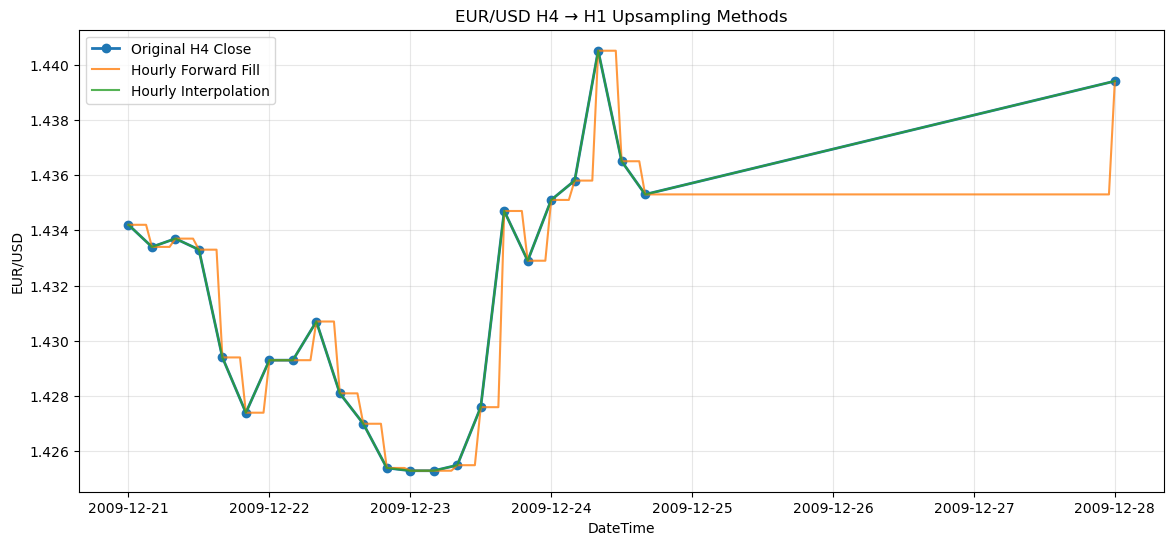

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(h4_sample.index, h4_sample["Close"], marker="o", label="Original H4 Close", linewidth=2)
plt.plot(hourly_ffill.index, hourly_ffill["Close"], label="Hourly Forward Fill", alpha=0.8)
plt.plot(hourly_interpolated.index, hourly_interpolated["Close"], label="Hourly Interpolation", alpha=0.8)
plt.xlabel("DateTime")
plt.ylabel("EUR/USD")
plt.title("EUR/USD H4 → H1 Upsampling Methods")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 18. Weekend gaps — an important Forex issue

Your H4 data contains normal market-closure gaps. Let's identify larger gaps.

In [22]:
large_gaps = time_differences[time_differences > pd.Timedelta(hours=4)]
print("Number of gaps larger than 4 hours:", len(large_gaps))
large_gaps.sort_values(ascending=False).head(20)

Number of gaps larger than 4 hours: 462


DateTime
2025-11-04 16:00:00   1643 days 00:00:00
2017-05-16 15:00:00   1305 days 19:00:00
2012-09-10 16:00:00     11 days 12:00:00
2017-12-26 07:00:00      3 days 12:00:00
2018-01-02 07:00:00      3 days 12:00:00
2009-12-28 00:00:00      3 days 08:00:00
2010-01-04 00:00:00      3 days 08:00:00
2020-12-27 23:00:00      3 days 04:00:00
2021-01-03 23:00:00      3 days 04:00:00
2012-09-24 16:00:00      2 days 20:00:00
2011-12-26 08:00:00      2 days 12:00:00
2011-01-03 00:00:00      2 days 08:00:00
2019-03-17 23:00:00      2 days 04:00:00
2019-05-19 23:00:00      2 days 04:00:00
2019-05-12 23:00:00      2 days 04:00:00
2019-05-05 23:00:00      2 days 04:00:00
2019-04-28 23:00:00      2 days 04:00:00
2019-04-21 23:00:00      2 days 04:00:00
2019-04-14 23:00:00      2 days 04:00:00
2019-12-01 23:00:00      2 days 04:00:00
Name: DateTime, dtype: timedelta64[ns]

### Why this matters

If you forward-fill across the complete calendar, Pandas can carry Friday's price through Saturday and Sunday.

That may help with some alignment tasks, but it does **not** mean EUR/USD traded continuously over the weekend.

# Part C — Practical analysis

## 19. Compare observation counts by frequency

In [23]:
frequency_summary = pd.DataFrame({
    "Frequency": ["H4", "Daily", "Weekly", "Monthly"],
    "Observations": [len(eurusd), len(daily), len(weekly), len(monthly)]
})

frequency_summary

,Frequency,Observations
0,H4,13351
1,Daily,2439
2,Weekly,451
3,Monthly,107


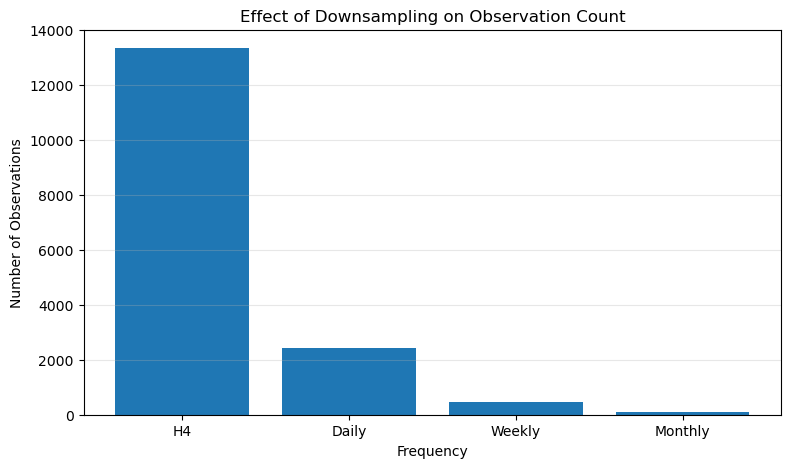

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(frequency_summary["Frequency"], frequency_summary["Observations"])
plt.xlabel("Frequency")
plt.ylabel("Number of Observations")
plt.title("Effect of Downsampling on Observation Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 20. Daily returns after downsampling

After creating a correct daily close series, calculate daily percentage returns.

$$
r_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$

In [25]:
daily["Return"] = daily["Close"].pct_change()
daily[["Close", "Return"]].head(10)

,Close,Return
DateTime,,
2009-12-21,1.42740,NaN
2009-12-22,1.42540,-0.00140
2009-12-23,1.43290,0.00526
2009-12-24,1.43530,0.00167
2009-12-28,1.43710,0.00125
2009-12-29,1.43500,-0.00146
2009-12-30,1.43350,-0.00105
2009-12-31,1.43310,-0.00028
2010-01-04,1.44120,0.00565


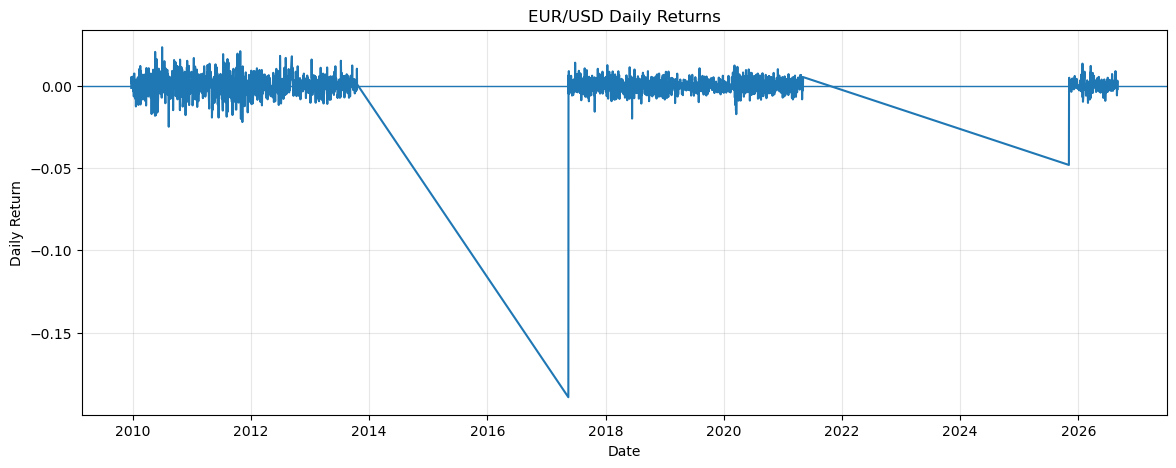

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["Return"])
plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("EUR/USD Daily Returns")
plt.grid(alpha=0.3)
plt.show()

# Part D — Exercises

## Exercise 1 — Frequency

1. Display the 10 most common time differences.
2. Confirm that 4 hours is the dominant interval.
3. Count gaps larger than 4 hours.
4. Explain why Forex data contains larger gaps.

In [27]:
# Write your Exercise 1 code here

## Exercise 2 — Daily downsampling

Create daily EUR/USD candles using:

- Open = first
- High = max
- Low = min
- Close = last

Then explain why the number of observations decreased.

In [28]:
# Write your Exercise 2 code here

## Exercise 3 — Weekly resampling

Create weekly candles ending on Friday and plot the most recent 52 weekly closing prices.

In [29]:
# Write your Exercise 3 code here

## Exercise 4 — Upsampling

Take a short H4 sample and convert it to H1 with:

1. `asfreq()`
2. forward fill
3. time interpolation

Compare the first 20 rows.

In [30]:
# Write your Exercise 4 code here

# Final Practice Task

Using `Data/EURUSD_H4.csv`:

1. Load and clean the H4 data.
2. Confirm the dominant H4 interval.
3. Create Daily, Weekly, and Monthly OHLC data.
4. Compare observation counts.
5. Plot recent H4 Close, Daily Close, and Weekly Close.
6. Upsample a short H4 period to H1 using `asfreq()`, `ffill()`, and interpolation.
7. Count the new missing timestamps.
8. Identify weekend gaps.
9. Explain why interpolated or forward-filled H1 values are not real H1 market candles.

In [31]:
# Write your complete final practice solution here

# Lesson 6 Cheat Sheet

## Downsampling

```python
# H4 → Daily
daily = eurusd.resample("1D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last"
})
```

```python
# H4 → Weekly
weekly = eurusd.resample("W-FRI").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last"
})
```

```python
# H4 → Monthly
monthly = eurusd.resample("ME").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last"
})
```

## Upsampling

```python
# H4 → H1 with NaN
hourly = eurusd[["Close"]].resample("1h").asfreq()
```

```python
# Forward fill
hourly_ffill = eurusd[["Close"]].resample("1h").ffill()
```

```python
# Interpolation
hourly_interpolated = (
    eurusd[["Close"]]
    .resample("1h")
    .asfreq()
    .interpolate(method="time")
)
```

# Lesson 6 Summary

You have now applied resampling directly to EUR/USD H4 data.

The most important financial-data rule is:

> **Do not create daily or weekly OHLC candles by simply averaging all H4 columns.**

Use first Open, maximum High, minimum Low, and last Close.

Also remember:

> Upsampled or interpolated timestamps are generated values, not newly observed market prices.